In [1]:
import sys
import os

from pandas.core.common import random_state

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


In [2]:
import importlib
# This part of your code directly loads MLP.py
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py'
module_name_for_direct_load = 'my_local_MLP_module' # Can be any unique name
spec = importlib.util.spec_from_file_location(module_name_for_direct_load, module_path)
if spec and spec.loader:
    neural_network = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(neural_network)
    MultiLayerPerceptron = neural_network.MultiLayerPerceptron
    print(f"Successfully loaded MLP directly from {module_path}")
else:
    print(f"Could not create spec for module at {module_path}")

lol
Successfully loaded MLP directly from /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py


In [3]:
output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/modelshyperparameter_tuning_results'
csv_filename = os.path.join(output_dir, 'mlp.csv')
df_existing = pd.read_csv(csv_filename)


In [4]:
df_existing = df_existing.sort_values(by="mcc", ascending=False)

In [5]:
display(df_existing)


,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
389,390,0.559665,0.595745,0.877419,21.301475,0.044444,88,0.000013,0.100000,1691,1024,RMSprop,0.000010,"[4000, 2000, 2000, 500]"
96,97,0.542649,0.636364,0.845161,33.214673,0.526042,184,0.000063,0.000281,421,1024,AdamW,0.010000,"[4000, 2000, 1000, 500]"
789,790,0.531527,0.565217,0.870968,14.986734,0.542544,40,0.001048,0.000110,1737,512,RMSprop,0.000010,"[2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
483,484,0.521786,0.588235,0.864516,30.227099,0.765015,90,0.000256,0.004715,1103,64,RMSprop,0.010000,"[4000, 2000, 1000, 500]"
820,821,0.507407,0.553191,0.864516,44.968081,0.317662,146,0.000012,0.079060,810,512,AdamW,0.000001,"[4000, 2000, 2000, 500]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42,43,-0.257957,0.153846,0.361290,29.779991,0.709277,156,0.004942,0.000002,385,256,RMSprop,0.010000,"[4000, 2000, 1000, 500]"
373,374,-0.286866,0.236025,0.206452,16.413601,0.375317,141,0.000047,0.000043,1883,512,RMSprop,0.010000,"[2000, 1000, 500]"
50,51,-0.318049,0.191781,0.238710,19.068785,0.378262,80,0.000041,0.000450,803,256,RMSprop,0.001000,"[4000, 2000, 2000, 500]"
374,375,-0.346903,0.254335,0.167742,20.208985,0.574549,109,0.000018,0.100000,503,512,RMSprop,0.001000,"[4000, 2000, 1000, 500]"


In [6]:
display(df_existing.iloc[0])

run_id                                  390
mcc                                0.559665
f1                                 0.595745
acc                                0.877419
duration_seconds                  21.301475
dropout_frac                       0.044444
patience                                 88
tol                                0.000013
weight_decay                            0.1
n_epochs                               1691
batch_size                             1024
optimizer                           RMSprop
lr                                  0.00001
neuron_layers       [4000, 2000, 2000, 500]
Name: 389, dtype: object

In [7]:
import random 
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score

In [8]:
df_existing

,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
389,390,0.559665,0.595745,0.877419,21.301475,0.044444,88,0.000013,0.100000,1691,1024,RMSprop,0.000010,"[4000, 2000, 2000, 500]"
96,97,0.542649,0.636364,0.845161,33.214673,0.526042,184,0.000063,0.000281,421,1024,AdamW,0.010000,"[4000, 2000, 1000, 500]"
789,790,0.531527,0.565217,0.870968,14.986734,0.542544,40,0.001048,0.000110,1737,512,RMSprop,0.000010,"[2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
483,484,0.521786,0.588235,0.864516,30.227099,0.765015,90,0.000256,0.004715,1103,64,RMSprop,0.010000,"[4000, 2000, 1000, 500]"
820,821,0.507407,0.553191,0.864516,44.968081,0.317662,146,0.000012,0.079060,810,512,AdamW,0.000001,"[4000, 2000, 2000, 500]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42,43,-0.257957,0.153846,0.361290,29.779991,0.709277,156,0.004942,0.000002,385,256,RMSprop,0.010000,"[4000, 2000, 1000, 500]"
373,374,-0.286866,0.236025,0.206452,16.413601,0.375317,141,0.000047,0.000043,1883,512,RMSprop,0.010000,"[2000, 1000, 500]"
50,51,-0.318049,0.191781,0.238710,19.068785,0.378262,80,0.000041,0.000450,803,256,RMSprop,0.001000,"[4000, 2000, 2000, 500]"
374,375,-0.346903,0.254335,0.167742,20.208985,0.574549,109,0.000018,0.100000,503,512,RMSprop,0.001000,"[4000, 2000, 1000, 500]"


In [9]:
best_results = df_existing.iloc[:10]

In [10]:
best_results = best_results.iloc[:, 5:]

In [11]:
best_results_mlp_dicts = []
for i,j in best_results.iterrows():
    best_results_mlp_dicts.append(dict(j))

In [12]:
best_results_mlp_dicts

[{'dropout_frac': 0.0444435099611828,
  'patience': 88,
  'tol': 1.3257113655901082e-05,
  'weight_decay': 0.1,
  'n_epochs': 1691,
  'batch_size': 1024,
  'optimizer': 'RMSprop',
  'lr': 1e-05,
  'neuron_layers': '[4000, 2000, 2000, 500]'},
 {'dropout_frac': 0.5260422505035018,
  'patience': 184,
  'tol': 6.250551925273976e-05,
  'weight_decay': 0.0002811768697974,
  'n_epochs': 421,
  'batch_size': 1024,
  'optimizer': 'AdamW',
  'lr': 0.01,
  'neuron_layers': '[4000, 2000, 1000, 500]'},
 {'dropout_frac': 0.5425436025735909,
  'patience': 40,
  'tol': 0.0010481131341546,
  'weight_decay': 0.0001098541141987,
  'n_epochs': 1737,
  'batch_size': 512,
  'optimizer': 'RMSprop',
  'lr': 1e-05,
  'neuron_layers': '[2048, 1024, 512, 256, 128, 64, 32, 16, 8]'},
 {'dropout_frac': 0.7650149482219141,
  'patience': 90,
  'tol': 0.0002559547922699,
  'weight_decay': 0.0047148663634573,
  'n_epochs': 1103,
  'batch_size': 64,
  'optimizer': 'RMSprop',
  'lr': 0.01,
  'neuron_layers': '[4000, 2000

In [13]:

df_existing_svc = pd.read_csv("res/svc_res_val_1.1.csv")
display(df_existing_svc)
df_existing_svc = df_existing_svc.sort_values(by="mcc", ascending=False)
df_existing_svc = df_existing_svc.iloc[:10].drop("Unnamed: 0", axis=1)
df_existing_svc = df_existing_svc.iloc[:, :6]

best_results_svc_dicts = []
for i,j in df_existing_svc.iterrows():
    best_results_svc_dicts.append(dict(j))
    

,Unnamed: 0,C,coef0,degree,gamma,kernel,shrinking,mcc,f1,acc
0,2306,1.0,0.0,2,scale,rbf,True,0.531527,0.565217,0.870968
1,2307,1.0,0.0,2,scale,rbf,False,0.531527,0.565217,0.870968
2,2354,1.0,0.0,3,scale,rbf,True,0.531527,0.565217,0.870968
3,2355,1.0,0.0,3,scale,rbf,False,0.531527,0.565217,0.870968
4,2402,1.0,0.0,4,scale,rbf,True,0.531527,0.565217,0.870968
...,...,...,...,...,...,...,...,...,...,...
5371,3743,10.0,1.0,3,1,sigmoid,False,-0.063372,0.235294,0.496774
5372,3790,10.0,1.0,4,1,sigmoid,True,-0.063372,0.235294,0.496774
5373,3791,10.0,1.0,4,1,sigmoid,False,-0.063372,0.235294,0.496774
5374,3838,10.0,1.0,5,1,sigmoid,True,-0.063372,0.235294,0.496774


In [14]:
best_results_svc_dicts

[{'C': 1.0,
  'coef0': 0.0,
  'degree': 2,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': True},
 {'C': 1.0,
  'coef0': 0.5,
  'degree': 2,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 5,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 5,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': True},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 4,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 4,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': True},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 3,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 3,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': True},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 2,
  'gamma': 'scale',
  'kernel': 'rbf',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 1.0,
  'degree': 2,
  'gamma': 'scal

In [16]:
df_existing_knn = pd.read_csv("res/knn_res_val_1.1.csv")
df_existing_knn = df_existing_knn.sort_values(by="mcc", ascending=False)
df_existing_knn = df_existing_knn.iloc[:10].drop("Unnamed: 0", axis=1)
df_existing_knn = df_existing_knn.iloc[:, :6]
best_results_knn_dicts = []
for i,j in df_existing_knn.iterrows():
    best_results_knn_dicts.append(dict(j))

,0,1,2,3,4,5,6,7,8,9,...,2390,2391,2392,2393,2394,2395,2396,2397,2398,2399
0,-0.296463,-1.014346,0.704087,0.197034,-0.199916,0.056990,-1.262282,-0.085669,-1.053805,0.296247,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,0.856668
1,-0.670941,-0.525577,-1.236676,1.502286,0.377970,-0.372174,-0.045401,-0.789457,0.021136,-0.509625,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.299228
2,0.629879,0.514115,-0.293469,1.144865,-1.295461,-1.086432,1.400654,1.220583,1.660234,-0.789349,...,-0.290593,6.044705,1.105679,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.866536
3,0.373012,-1.030634,0.820882,0.936072,-0.378374,1.713116,1.237002,-0.435967,-0.914606,1.251034,...,-0.290593,-0.165434,1.105679,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.567226
4,-1.172401,0.684663,-0.397464,-1.756755,1.804830,0.697231,-0.604966,-1.927427,-0.766635,-1.374831,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,1.510832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,-1.193043,-0.487364,-0.908142,1.116066,-0.271553,-0.376130,-0.633163,0.123939,1.031423,0.226711,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.918624
790,1.125096,1.186714,-0.128442,-0.240725,-1.569522,-0.687927,1.238028,0.160632,-1.380454,0.755241,...,-0.290593,-0.165434,0.291367,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,0.891481
791,-0.823325,-0.610447,-0.668821,1.034534,-0.353845,-0.572354,-0.119446,0.004899,1.136635,0.244145,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.984171
792,-0.336960,-1.640396,-0.558868,0.358328,-0.148476,0.579681,-1.060386,0.396513,-0.133678,0.005032,...,-0.290593,-0.165434,0.437196,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.059823


'SVC'

0.5315270296169605

0.5315270296169605

0.5315270296169605

...

0.29855619650098675

0.29855619650098675

0.29855619650098675

0.29855619650098675

RESULTS FOR CYCLE KNN#1
Accuracy: 0.8171
F1-Score: 0.4643
MCC: 0.3667
RESULTS FOR CYCLE SVC#1
Accuracy: 0.7927
F1-Score: 0.2609
MCC: 0.1905


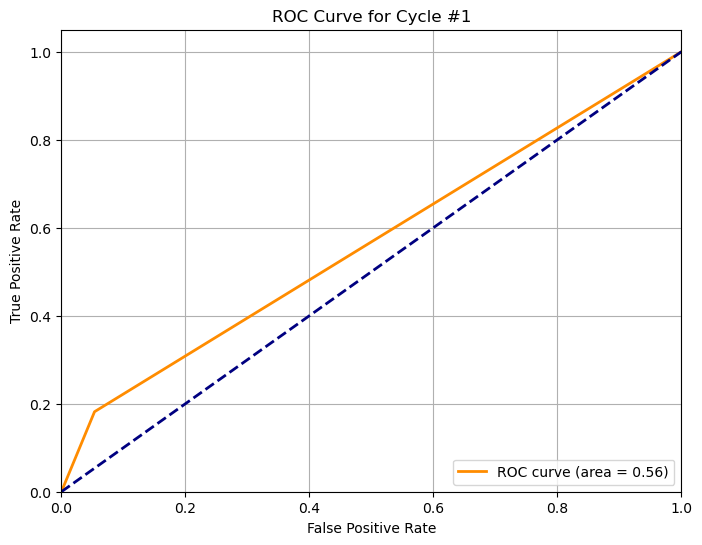

0.4472171448001235

0.0

0.5024511347953579

0.2867696673382022

0.3919831548048891

...

0.5024511347953579

0.5024511347953579

0.5024511347953579

0.3919831548048891

RESULTS FOR CYCLE MLP#1
Accuracy: 0.7927
F1-Score: 0.2609
MCC: 0.1905


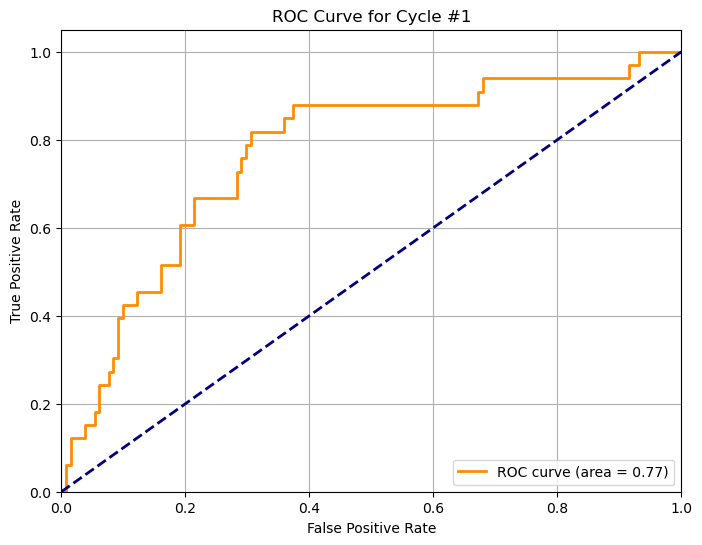

,0,1,2,3,4,5,6,7,8,9,...,2438,2439,2440,2441,2442,2443,2444,2445,2446,2447
0,-0.358018,-1.035540,0.662697,0.203512,-0.242572,0.027387,-1.193534,-0.033363,-0.992733,0.343211,...,-0.171860,-0.657442,-0.120636,-0.251358,-0.260449,-0.160464,-0.367228,-0.111571,-0.298807,0.789415
1,-0.757569,-0.552590,-1.294893,1.492533,0.295737,-0.390662,0.026351,-0.729851,0.067791,-0.470612,...,-0.171860,-0.657442,-0.120636,-0.251358,-0.260449,-0.160464,-0.367228,-0.111571,-0.298807,-0.316174
2,0.630347,0.474721,-0.343508,1.139557,-1.263085,-1.086422,1.475974,1.259339,1.684905,-0.753095,...,5.818689,1.124957,-0.120636,-0.251358,-0.260449,-0.160464,-0.367228,-0.111571,-0.298807,-0.858790
3,-0.353872,0.177352,-0.347391,0.865647,-0.722119,-0.843343,-1.351930,1.321145,1.530084,-0.867012,...,-0.171860,-0.657442,-0.120636,-0.251358,3.839523,-0.160464,-0.367228,-0.111571,-0.298807,-2.062326
4,-0.150137,1.483352,0.823310,1.958364,-1.149519,-1.352437,1.070247,1.187962,0.660233,0.545490,...,-0.171860,-0.657442,-0.120636,-0.251358,-0.260449,-0.160464,-0.367228,-0.111571,-0.298807,-1.723874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,0.470838,-0.470245,-1.413397,0.053004,0.876278,-0.488682,-0.742034,0.296229,-0.112025,-0.307851,...,-0.171860,-0.657442,-0.120636,-0.251358,-0.260449,-0.160464,-0.367228,-0.111571,-0.186901,-0.481796
790,0.241741,0.527734,-0.406549,-0.147129,0.481211,0.174144,-1.397002,-0.726157,-0.487640,0.668516,...,-0.171860,-0.657442,-0.120636,-0.251358,-0.260449,-0.160464,0.882678,-0.111571,1.608118,0.362637
791,-0.068486,-0.503224,0.114226,-0.334119,0.359536,0.604212,-0.817256,-0.780311,-0.001767,0.567025,...,-0.171860,-0.657442,-0.120636,-0.251358,-0.260449,-0.160464,1.136677,-0.111571,1.995632,0.113362
792,-0.985367,-0.832982,-1.231560,1.527569,0.313391,-0.299423,-0.204487,-0.359213,-0.048201,0.064195,...,-0.171860,-0.657442,-0.120636,-0.251358,-0.260449,-0.160464,-0.367228,-0.111571,-0.298807,-0.277579


'SVC'

0.5764419652771503

0.5764419652771503

0.5764419652771503

...

0.3831014143813623

0.3831014143813623

0.3831014143813623

0.3831014143813623

RESULTS FOR CYCLE KNN#2
Accuracy: 0.6890
F1-Score: 0.2388
MCC: 0.0435
RESULTS FOR CYCLE SVC#2
Accuracy: 0.7134
F1-Score: 0.2295
MCC: 0.0552


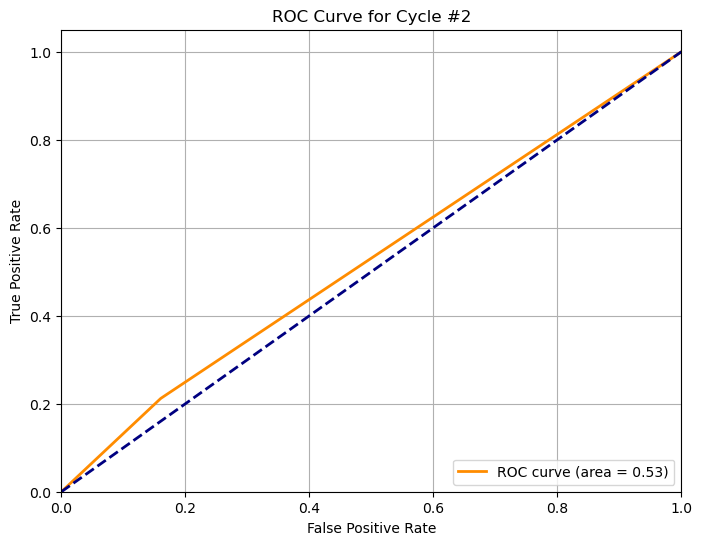

0.43493661551390117

0.0

0.4793489256961887

0.3786408191624803

0.43493661551390117

...

0.4793489256961887

0.4638888888888889

0.4915502744287339

0.4491044290045257

RESULTS FOR CYCLE MLP#2
Accuracy: 0.7561
F1-Score: 0.1667
MCC: 0.0518


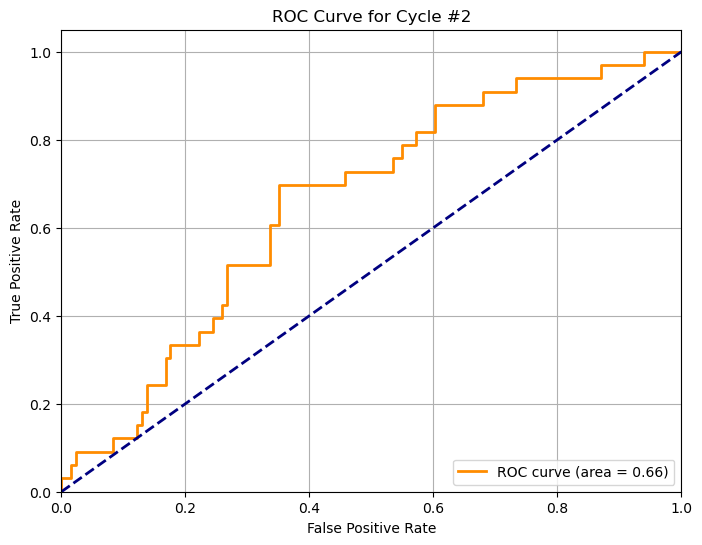

,0,1,2,3,4,5,6,7,8,9,...,2410,2411,2412,2413,2414,2415,2416,2417,2418,2419
0,-0.304461,-1.083046,0.711739,0.177182,-0.243194,0.040077,-1.262431,-0.032693,-1.090796,0.282256,...,-0.183726,-0.647090,-0.128831,-0.285793,-0.177705,-0.200847,-0.32095,-0.11134,-0.302182,0.849243
1,-0.684256,-0.601918,-1.255379,1.474275,0.338272,-0.404545,-0.076855,-0.743553,0.037000,-0.542963,...,-0.183726,-0.647090,-0.128831,-0.285793,-0.177705,-0.200847,-0.32095,-0.11134,-0.302182,-0.370130
2,0.635032,0.421519,-0.299363,1.119089,-1.345525,-1.144530,1.331999,1.286686,1.756691,-0.829401,...,5.442885,1.030550,-0.128831,-0.285793,-0.177705,-0.200847,-0.32095,-0.11134,-0.302182,-0.968591
3,-0.106859,1.426346,0.873133,1.943024,-1.222855,-1.427454,0.937682,1.213837,0.667021,0.487367,...,-0.183726,-0.647090,-0.128831,-0.285793,-0.177705,-0.200847,-0.32095,-0.11134,-0.302182,-1.922707
4,-0.611232,0.028585,-0.065764,0.902454,-0.844721,0.273270,0.458203,0.128392,0.523177,-1.913877,...,-0.183726,-0.647090,-0.128831,-0.285793,5.627314,4.978903,-0.32095,-0.11134,-0.302182,-1.195164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793,-0.730602,-0.793514,-1.568204,1.562630,0.411101,-0.337260,-0.094295,-0.244615,-0.029764,-0.028809,...,-0.183726,-0.647090,-0.128831,-0.285793,-0.177705,-0.200847,-0.32095,-0.11134,-0.302182,-0.309789
794,-0.702294,-0.649934,-0.074235,-0.002576,-1.055714,-0.342764,1.118129,0.187702,1.104792,0.030555,...,-0.183726,1.030550,-0.128831,-0.285793,-0.177705,-0.200847,-0.32095,-0.11134,-0.302182,-0.361202
795,-0.843986,-0.695166,-1.066199,1.469486,0.205996,-0.435515,-0.284881,-0.541531,0.127106,-0.260675,...,-0.183726,-0.647090,-0.128831,-0.285793,-0.177705,-0.200847,-0.32095,-0.11134,-0.302182,-0.493015
796,0.288426,-0.359973,-1.307239,-0.088361,0.731140,-0.668016,-0.594911,-0.127395,-0.478374,-0.670633,...,-0.183726,0.050281,-0.128831,-0.285793,-0.177705,-0.200847,-0.32095,-0.11134,-0.302182,-0.323406


'SVC'

0.6613336561255667

0.6613336561255667

0.6613336561255667

...

0.2631664772044886

0.2631664772044886

0.2631664772044886

0.2631664772044886

RESULTS FOR CYCLE KNN#3
Accuracy: 0.7284
F1-Score: 0.1538
MCC: 0.0062
RESULTS FOR CYCLE SVC#3
Accuracy: 0.7778
F1-Score: 0.1429
MCC: 0.0781


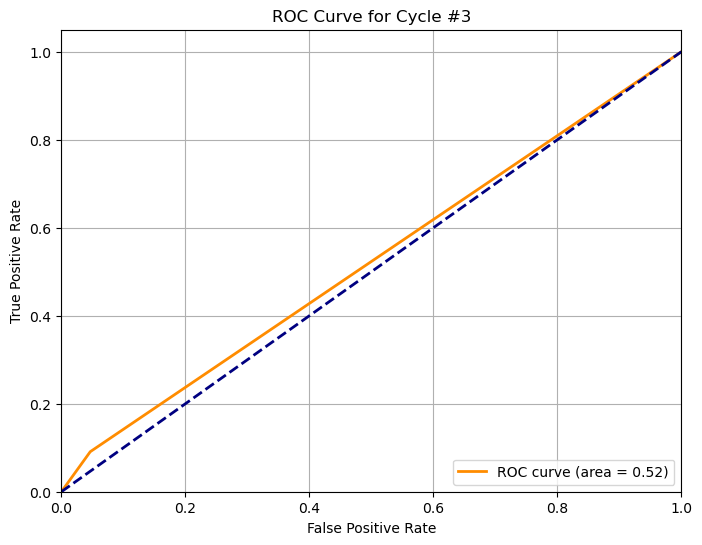

0.6443005142861207

0.0

0.6028557990961162

0.4241828086519717

0.6613336561255667

...

0.5764386444017885

0.5577144228352958

0.6683131841264952

0.6613336561255667

RESULTS FOR CYCLE MLP#3
Accuracy: 0.7654
F1-Score: 0.0500
MCC: -0.0321


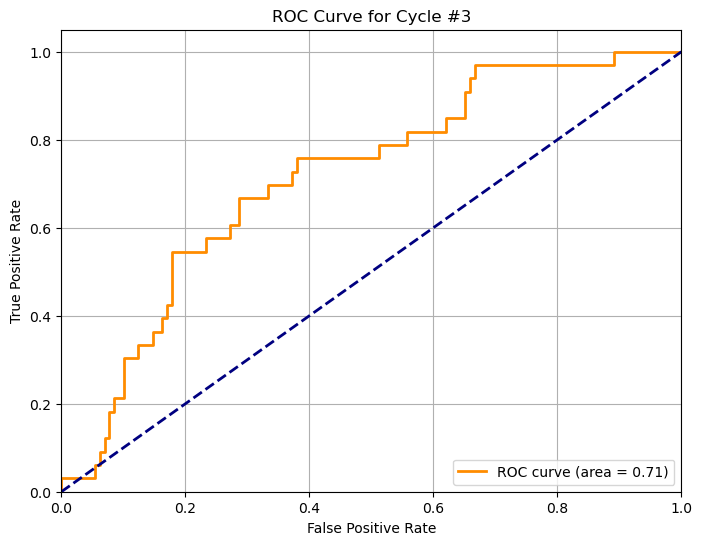

,0,1,2,3,4,5,6,7,8,9,...,2383,2384,2385,2386,2387,2388,2389,2390,2391,2392
0,-0.282986,-1.020491,0.725741,0.170440,-0.213673,0.079214,-1.160727,-0.109508,-1.050962,0.325002,...,-0.164742,-0.623188,-0.111111,-0.259317,-0.250270,-0.177332,-0.306279,-0.090536,-0.297482,0.861830
1,-0.654614,-0.533383,-1.236235,1.489968,0.348250,-0.352743,0.016847,-0.806282,0.042026,-0.517231,...,-0.164742,-0.623188,-0.111111,-0.259317,-0.250270,-0.177332,-0.306279,-0.090536,-0.297482,-0.278467
2,0.636305,0.502775,-0.282718,1.128638,-1.278954,-1.071651,1.416191,1.183727,1.708643,-0.809575,...,6.070103,1.043163,-0.111111,-0.259317,-0.250270,-0.177332,-0.306279,-0.090536,-0.297482,-0.838118
3,-0.279130,0.202845,-0.286610,0.848246,-0.714257,-0.820484,-1.313630,1.245559,1.549083,-0.927469,...,-0.164742,-0.623188,-0.111111,-0.259317,3.995687,-0.177332,-0.306279,-0.090536,-0.297482,-2.079438
4,0.381393,-1.036724,0.843812,0.917561,-0.387201,1.746122,1.257825,-0.456314,-0.909425,1.322869,...,-0.164742,1.043163,-0.111111,-0.259317,-0.250270,-0.177332,-0.306279,-0.090536,-0.297482,-0.542848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
797,-0.601109,-0.608369,-0.272642,1.325953,0.211006,-0.108035,-0.259986,-0.214229,0.120698,0.180529,...,-0.164742,-0.623188,-0.111111,-0.259317,-0.250270,-0.177332,-0.306279,-0.090536,-0.297482,-0.575583
798,-0.689334,0.042309,-0.565812,0.385714,-0.673701,-0.745162,-1.073763,-0.522674,0.751187,0.076049,...,-0.164742,2.709515,-0.111111,-0.259317,-0.250270,-0.177332,-0.306279,9.944667,-0.297482,0.722964
799,-0.717384,-1.755103,-0.826912,-0.522687,0.904075,1.335110,-0.966872,-1.060813,-1.490084,-2.993034,...,-0.164742,-0.623188,-0.111111,-0.259317,-0.250270,-0.177332,-0.306279,-0.090536,-0.297482,1.162828
800,1.199448,1.312170,-0.661275,-0.060620,-1.587637,-0.493488,1.229864,0.331209,-0.859044,0.606851,...,-0.164742,1.043163,-0.111111,-0.259317,-0.250270,-0.177332,-0.306279,-0.090536,-0.297482,1.035729


'SVC'

0.5166748622481384

0.5166748622481384

0.5166748622481384

...

0.3674234614174767

0.3674234614174767

0.3674234614174767

0.3674234614174767

RESULTS FOR CYCLE KNN#4
Accuracy: 0.7812
F1-Score: 0.2222
MCC: 0.1481
RESULTS FOR CYCLE SVC#4
Accuracy: 0.7937
F1-Score: 0.2326
MCC: 0.1875


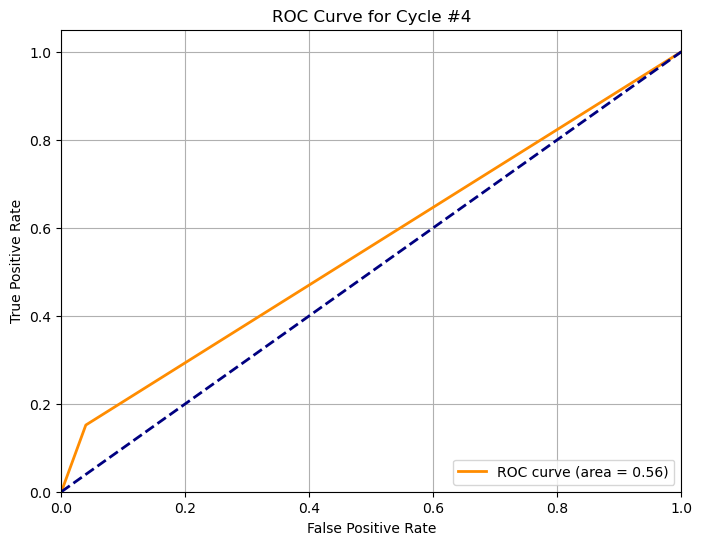

0.5690229068732003

0.0

0.5430376436591353

0.39508721327563373

0.435643582470948

...

0.5605549547772328

0.5715476066494082

0.6024277345316768

0.4491044290045257

RESULTS FOR CYCLE MLP#4
Accuracy: 0.7812
F1-Score: 0.3137
MCC: 0.2096


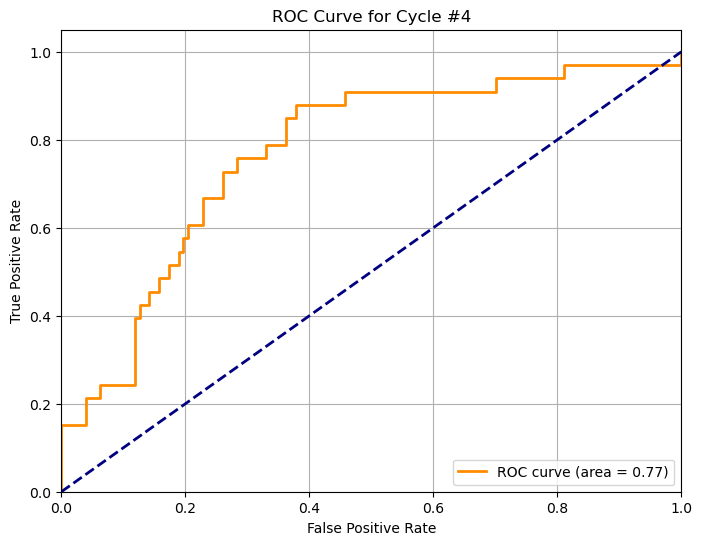

,0,1,2,3,4,5,6,7,8,9,...,2380,2381,2382,2383,2384,2385,2386,2387,2388,2389
0,-0.684201,-0.502855,-1.307992,1.519558,0.303721,-0.471824,-0.027705,-0.722198,0.100437,-0.525442,...,-0.290593,-0.171860,-0.641630,-0.101745,-0.290593,-0.178080,-0.191083,-0.332165,-0.090106,-0.402254
1,0.601759,0.543149,-0.342305,1.165911,-1.371472,-1.195684,1.430957,1.279282,1.795333,-0.810812,...,-0.290593,5.818689,1.015065,-0.101745,-0.290593,-0.178080,-0.191083,-0.332165,-0.090106,-0.991004
2,-0.613022,0.141550,-0.106341,0.950215,-0.873227,0.191220,0.526269,0.137396,0.579605,-1.891241,...,-0.290593,-0.171860,-0.641630,-0.101745,-0.290593,5.615455,4.716725,-0.332165,-0.090106,-1.213901
3,0.347826,-1.010979,0.798605,0.959322,-0.453419,1.641501,1.265878,-0.370213,-0.867159,1.270759,...,-0.290593,-0.171860,1.015065,-0.101745,-0.290593,-0.178080,-0.191083,-0.332165,-0.090106,-0.680381
4,-1.179932,0.714733,-0.448778,-1.705070,1.732084,0.611958,-0.592148,-1.855320,-0.714151,-1.408113,...,-0.290593,-0.171860,-0.641630,-0.101745,-0.290593,-0.178080,-0.191083,-0.332165,-0.090106,1.476223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,-0.078798,0.248075,-0.253851,-0.502349,-0.337208,0.600730,-1.237237,-0.398114,0.822782,0.314521,...,-0.290593,-0.171860,-0.590773,-0.101745,-0.290593,-0.178080,-0.191083,2.424339,-0.090106,-0.330790
790,1.394281,-0.965514,-0.947575,-0.333323,1.110933,1.264287,-0.935961,-0.908997,-0.643867,-1.343282,...,-0.290593,-0.171860,0.148452,-0.101745,-0.290593,-0.178080,-0.191083,-0.332165,-0.090106,0.282227
791,-0.831705,-0.888530,-0.622057,1.211849,-0.439314,-0.819490,-0.212910,0.028693,1.026757,0.324141,...,-0.290593,-0.171860,-0.641630,-0.101745,-0.290593,-0.178080,-0.191083,-0.332165,-0.090106,-1.040738
792,0.144377,-1.127067,-0.950716,0.239214,1.434795,-0.531550,-1.041081,-0.226606,-0.305372,-0.919972,...,-0.290593,-0.171860,-0.641630,-0.101745,-0.290593,-0.178080,-0.191083,-0.332165,0.939009,-0.469539


'SVC'

0.5605549547772328

0.5605549547772328

0.5605549547772328

...

0.18778121925944147

0.18778121925944147

0.18778121925944147

0.18778121925944147

RESULTS FOR CYCLE KNN#5
Accuracy: 0.8049
F1-Score: 0.3600
MCC: 0.2784
RESULTS FOR CYCLE SVC#5
Accuracy: 0.8171
F1-Score: 0.2500
MCC: 0.2702


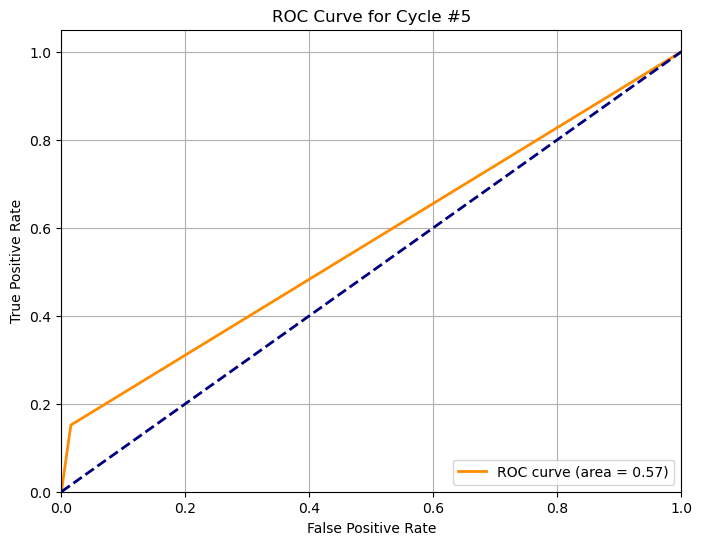

0.5339961198529422

0.0

0.40905951627605935

0.2867696673382022

0.55

...

0.3148213574395854

0.29837582508026245

0.43862683481472853

0.55

RESULTS FOR CYCLE MLP#5
Accuracy: 0.8049
F1-Score: 0.2381
MCC: 0.2130


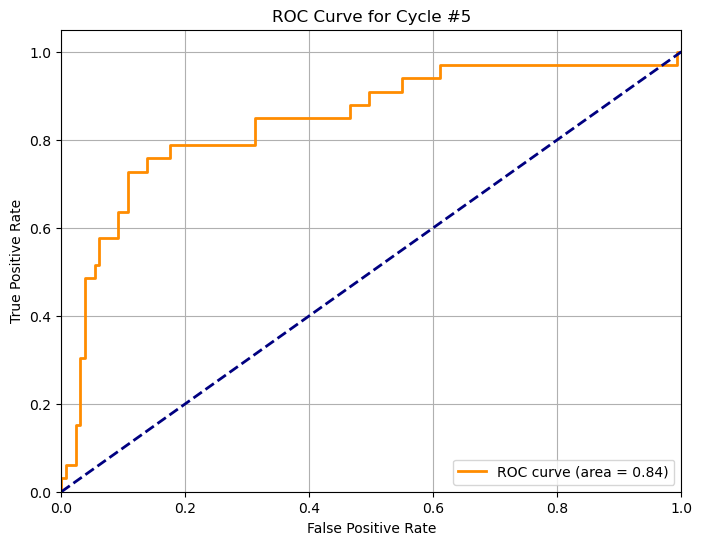

,0,1,2,3,4,5,6,7,8,9,...,2395,2396,2397,2398,2399,2400,2401,2402,2403,2404
0,-0.267958,-0.999242,0.661787,0.156702,-0.170127,0.031974,-1.249044,-0.092461,-1.034039,0.345817,...,-0.280976,-0.151225,-0.578980,-0.120137,-0.276743,-0.25027,-0.146124,-0.325321,-0.083771,0.834175
1,-0.646344,-0.508315,-1.271315,1.440828,0.404980,-0.394798,-0.057630,-0.790759,0.072875,-0.474005,...,-0.280976,-0.151225,-0.578980,-0.120137,-0.276743,-0.25027,-0.146124,-0.325321,-0.083771,-0.307921
2,0.668051,0.535965,-0.331831,1.089193,-1.260403,-1.105077,1.358161,1.203601,1.760725,-0.758571,...,-0.280976,6.612660,1.270749,-0.120137,-0.276743,-0.25027,-0.146124,-0.325321,-0.083771,-0.868455
3,-0.574401,-0.646772,0.250515,0.125305,-0.132036,-1.748221,-0.538872,0.365100,0.563834,-1.156499,...,-0.280976,-0.151225,-0.578980,-0.120137,-0.276743,-0.25027,-0.146124,-0.325321,-0.083771,-1.302383
4,0.408504,-1.015602,0.778121,0.883778,-0.347726,1.678874,1.197934,-0.440026,-0.890699,1.317132,...,-0.280976,-0.151225,1.270749,-0.120137,-0.276743,-0.25027,-0.146124,-0.325321,-0.083771,-0.572719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,1.251623,1.127523,-0.669977,-0.040836,-1.651127,-0.854634,1.332872,0.639948,-1.223515,0.877998,...,-0.280976,-0.151225,1.067766,-0.120137,-0.276743,-0.25027,-0.146124,-0.325321,-0.083771,0.954361
800,-0.894098,-0.409977,-1.271016,-0.347601,0.405935,0.481346,-0.226193,0.645107,-0.035078,-0.614093,...,-0.280976,-0.151225,0.427907,-0.120137,-0.276743,-0.25027,-0.146124,1.203215,11.133844,-1.694565
801,0.978914,1.462890,-0.460439,-0.130793,-1.628128,-0.634431,0.984417,0.405235,-0.866753,0.592808,...,-0.280976,-0.151225,1.270749,-0.120137,-0.276743,-0.25027,-0.146124,-0.325321,-0.083771,0.956811
802,-0.380266,-1.004789,-0.504956,0.102646,-0.781828,-0.182738,0.562470,-0.260262,0.610690,0.924864,...,-0.280976,-0.151225,1.270749,-0.120137,-0.276743,-0.25027,-0.146124,-0.325321,-0.083771,0.518704


'SVC'

0.27268340843223593

0.27268340843223593

0.27268340843223593

...

0.2597735461291727

0.2597735461291727

0.2597735461291727

0.2597735461291727

RESULTS FOR CYCLE KNN#6
Accuracy: 0.8050
F1-Score: 0.2791
MCC: 0.2507
RESULTS FOR CYCLE SVC#6
Accuracy: 0.8113
F1-Score: 0.3182
MCC: 0.2883


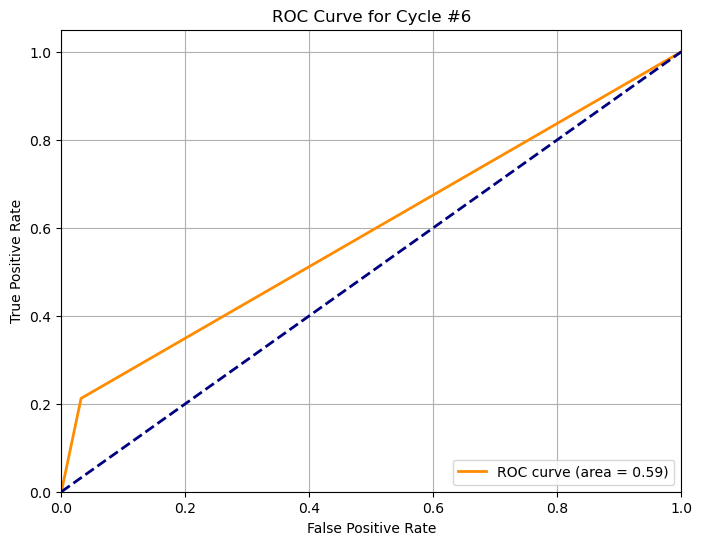

0.25661655550655454

0.0

0.30819528191916734

0.1448527186270677

0.23826900458944678

...

0.23707286610598735

0.23707286610598735

0.27350843390649243

0.23826900458944678

RESULTS FOR CYCLE MLP#6
Accuracy: 0.7987
F1-Score: 0.2000
MCC: 0.1925


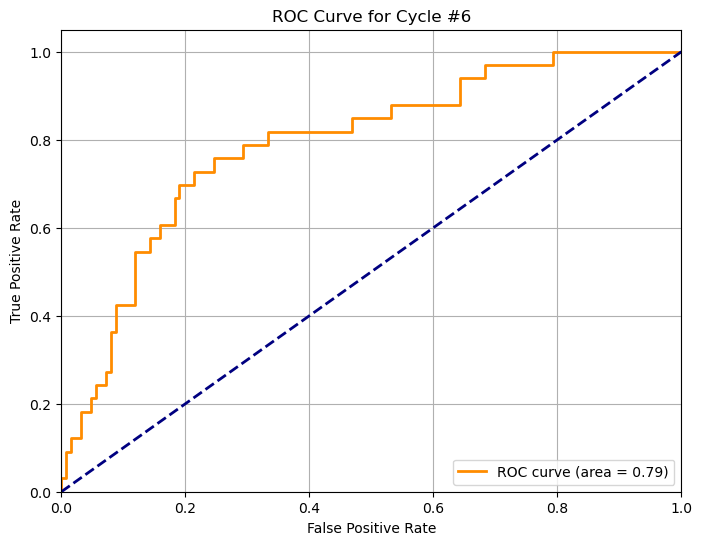

,0,1,2,3,4,5,6,7,8,9,...,2372,2373,2374,2375,2376,2377,2378,2379,2380,2381
0,-0.333073,-1.095947,0.698059,0.219648,-0.218073,-0.027209,-1.249874,-0.054339,-1.022575,0.350790,...,-0.157622,-0.607735,-0.090259,-0.288359,-0.220746,-0.159297,-0.319159,-0.078087,-0.280056,0.846546
1,-0.710196,-0.595015,-1.236996,1.524635,0.350067,-0.456131,-0.048773,-0.754724,0.093647,-0.473439,...,-0.157622,-0.607735,-0.090259,-0.288359,-0.220746,-0.159297,-0.319159,-0.078087,-0.280056,-0.361568
2,0.599810,0.470548,-0.296562,1.167287,-1.295139,-1.169988,1.378528,1.245598,1.795692,-0.759534,...,6.344289,1.237841,-0.090259,-0.288359,-0.220746,-0.159297,-0.319159,-0.078087,-0.280056,-0.954504
3,-0.329160,0.162107,-0.300401,0.889985,-0.724195,-0.920586,-1.405832,1.307751,1.632740,-0.874908,...,-0.157622,-0.607735,-0.090259,-0.288359,4.530093,-0.159297,-0.319159,-0.078087,-0.280056,-2.269650
4,-0.136862,1.516735,0.856823,1.996237,-1.175280,-1.442922,0.979049,1.173823,0.717204,0.555656,...,-0.157622,-0.607735,-0.090259,-0.288359,-0.220746,-0.159297,-0.319159,-0.078087,-0.280056,-1.899811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
803,-1.125791,0.962393,0.659736,0.673743,0.041320,0.153075,2.040870,0.129149,-0.493063,0.011904,...,-0.157622,-0.405209,-0.090259,-0.288359,-0.220746,0.458768,-0.319159,-0.078087,-0.280056,1.238275
804,-0.908947,-1.026409,-0.385479,-0.558029,-0.160409,-0.651237,1.543919,-0.157147,1.012533,0.269377,...,-0.157622,1.237841,-0.090259,-0.288359,-0.220746,-0.159297,-0.319159,-0.078087,1.816085,-0.001989
805,0.621089,-0.686582,-0.979547,0.156615,0.534512,-0.798543,-0.064991,-0.554031,-0.421730,-0.231465,...,-0.157622,0.536767,-0.090259,-0.288359,-0.220746,1.980222,-0.319159,-0.078087,-0.280056,1.073526
806,-0.429144,-0.494116,0.639121,1.785521,-0.189723,0.591216,0.908211,-0.381611,-0.594647,-1.072849,...,-0.157622,-0.607735,-0.090259,-0.288359,-0.220746,3.910693,-0.319159,-0.078087,-0.280056,1.199073


'SVC'

0.29132338067902397

0.29132338067902397

0.29132338067902397

...

0.2328958333852522

0.2328958333852522

0.2328958333852522

0.2328958333852522

RESULTS FOR CYCLE KNN#7
Accuracy: 0.7821
F1-Score: 0.3200
MCC: 0.2140
RESULTS FOR CYCLE SVC#7
Accuracy: 0.8205
F1-Score: 0.3913
MCC: 0.3404


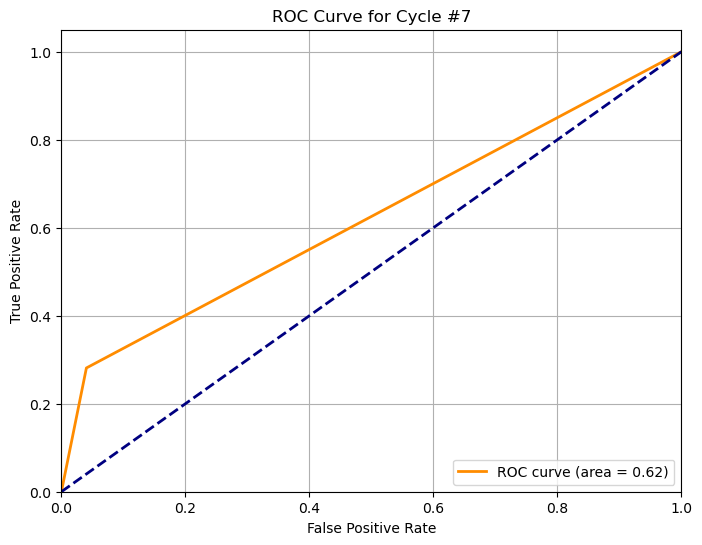

0.27742003682655036

0.22883834436313075

0.30819528191916734

0.2857141030430769

0.27742003682655036

...

0.25524543172160113

0.25524543172160113

0.32296545537718724

0.27742003682655036

RESULTS FOR CYCLE MLP#7
Accuracy: 0.7885
F1-Score: 0.3265
MCC: 0.2299


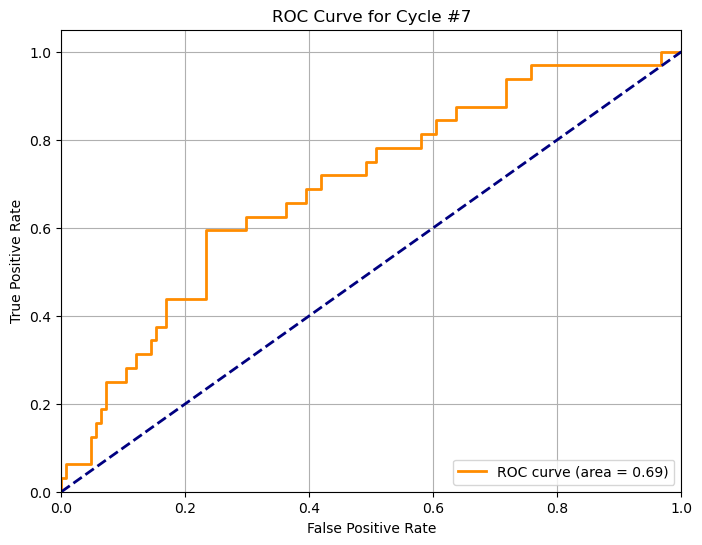

,0,1,2,3,4,5,6,7,8,9,...,2376,2377,2378,2379,2380,2381,2382,2383,2384,2385
0,-0.311043,-1.034715,0.696591,0.168089,-0.166309,0.028294,-1.215101,-0.071879,-1.094143,0.332669,...,-0.170961,-0.627265,-0.101222,-0.267842,-0.231125,-0.136364,-0.354532,-0.120014,-0.309121,0.883579
1,-0.682373,-0.554087,-1.313995,1.476819,0.392614,-0.392721,-0.021638,-0.770553,0.057287,-0.489338,...,-0.170961,-0.627265,-0.101222,-0.267842,-0.231125,-0.136364,-0.354532,-0.120014,-0.309121,-0.303295
2,0.607510,0.468285,-0.336854,1.118446,-1.225902,-1.093416,1.396587,1.224881,1.813016,-0.774662,...,5.849298,1.160258,-0.101222,-0.267842,-0.231125,-0.136364,-0.354532,-0.120014,-0.309121,-0.885806
3,-0.307191,0.172346,-0.340842,0.840348,-0.664220,-0.848613,-1.370067,1.286882,1.644925,-0.889724,...,-0.170961,-0.627265,-0.101222,-0.267842,4.326662,-0.136364,-0.354532,-0.120014,-0.309121,-2.177829
4,0.352802,-1.050732,0.817587,0.909096,-0.338910,1.652972,1.236084,-0.419631,-0.945038,1.306572,...,-0.170961,1.160258,-0.101222,-0.267842,-0.231125,-0.136364,-0.354532,-0.120014,-0.309121,-0.578475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,0.357832,-0.514486,-1.419152,0.081989,0.955669,-0.577276,-0.525640,0.004038,-0.222267,-0.516136,...,-0.170961,-0.157326,-0.101222,-0.267842,-0.231125,-0.136364,-0.354532,-0.120014,-0.309121,-0.375161
800,0.403779,-0.387242,-1.360390,0.050086,1.035406,-0.429440,-0.683769,0.305251,-0.138804,-0.218216,...,-0.170961,-0.627265,-0.101222,-0.267842,-0.231125,-0.136364,-0.354532,-0.120014,-0.309121,-0.454042
801,-0.062743,0.182985,-0.243281,-0.550996,-0.224763,0.641749,-1.177481,-0.454552,0.797781,0.369110,...,-0.170961,-0.553444,-0.101222,-0.267842,-0.231125,-0.136364,2.109677,-0.120014,3.088620,-0.226744
802,1.121045,1.248179,0.004360,0.056862,-1.353532,-0.892395,1.602578,0.423389,-1.123954,1.204944,...,-0.170961,-0.523832,-0.101222,-0.267842,-0.231125,-0.136364,-0.354532,-0.120014,-0.309121,1.066010


'SVC'

0.1938599993459332

0.1938599993459332

0.1938599993459332

...

0.23549611923520117

0.23549611923520117

0.23549611923520117

0.23549611923520117

RESULTS FOR CYCLE KNN#8
Accuracy: 0.7799
F1-Score: 0.3396
MCC: 0.2268
RESULTS FOR CYCLE SVC#8
Accuracy: 0.7925
F1-Score: 0.2667
MCC: 0.2060


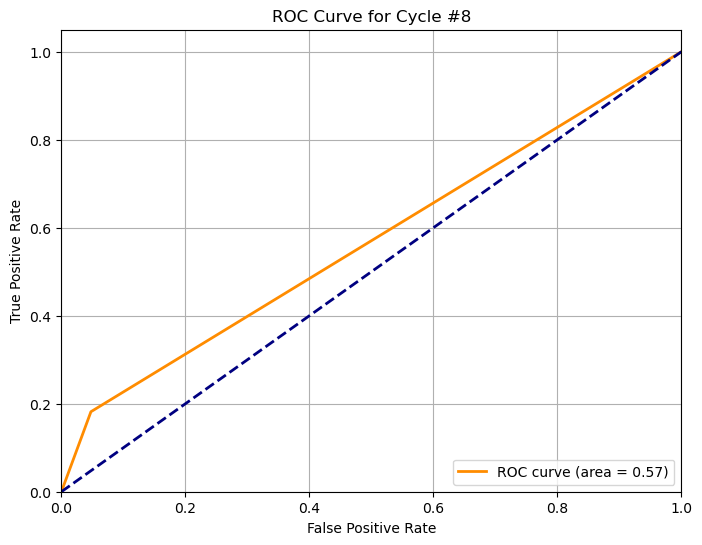

0.29837582508026245

0.0

0.316838587686983

0.32857142857142857

0.30138708937625097

...

0.2631664772044886

0.28151517481442034

0.40905951627605935

0.30138708937625097

RESULTS FOR CYCLE MLP#8
Accuracy: 0.7736
F1-Score: 0.3077
MCC: 0.1939


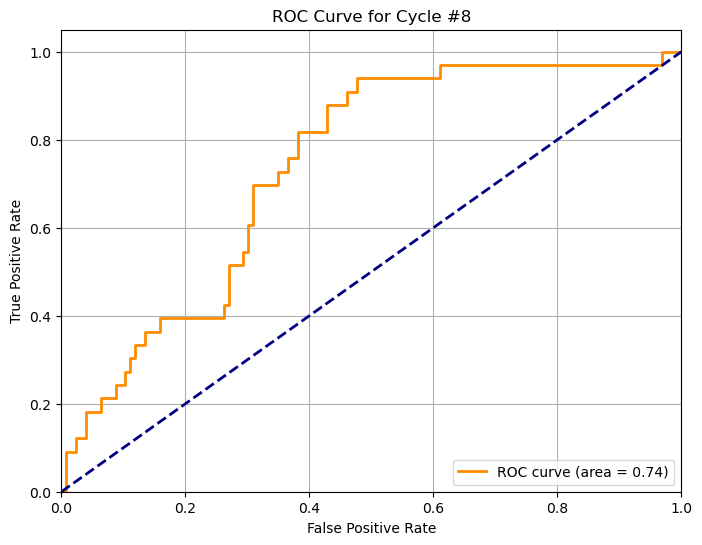

,0,1,2,3,4,5,6,7,8,9,...,2354,2355,2356,2357,2358,2359,2360,2361,2362,2363
0,-0.306471,-1.067889,0.682977,0.161291,-0.230522,-0.012011,-1.200112,-0.055899,-1.041730,0.297976,...,-0.151383,-0.622335,-0.078406,-0.285478,-0.216583,-0.178799,-0.283314,-0.090629,-0.272760,0.820044
1,-0.694425,-0.567797,-1.311668,1.428121,0.338898,-0.435178,0.009073,-0.746485,0.069185,-0.572905,...,-0.151383,-0.622335,-0.078406,-0.285478,-0.216583,-0.178799,-0.283314,-0.090629,-0.272760,-0.321682
2,0.653205,0.495981,-0.342274,1.081222,-1.310017,-1.139455,1.445982,1.225851,1.763137,-0.875194,...,6.605783,1.065878,-0.078406,-0.285478,-0.216583,-0.178799,-0.283314,-0.090629,-0.272760,-0.882034
3,-0.104624,1.540414,0.846629,1.885933,-1.189888,-1.408727,1.043813,1.155080,0.689777,0.514437,...,-0.151383,-0.622335,-0.078406,-0.285478,-0.216583,-0.178799,-0.283314,-0.090629,-0.272760,-1.775394
4,0.387095,-1.084554,0.803014,0.878574,-0.406365,1.620974,1.283365,-0.399625,-0.897872,1.329786,...,-0.151383,1.065878,-0.078406,-0.285478,-0.216583,-0.178799,-0.283314,-0.090629,-0.272760,-0.586394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,2.401447,-1.581843,-0.105295,-0.823202,1.068039,2.530240,-0.580348,-1.402874,-0.752379,-2.408214,...,-0.151383,1.058840,-0.078406,-0.285478,-0.216583,-0.178799,-0.270708,-0.090629,-0.272760,1.162348
796,-0.000903,-0.251836,-1.349622,0.048979,-0.166006,-0.964649,0.398068,-0.002433,0.444727,-0.029480,...,-0.151383,1.065878,-0.078406,-0.285478,-0.216583,-0.178799,-0.283314,-0.090629,-0.272760,0.551520
797,1.513672,-0.127768,-0.041678,1.014939,-0.399897,0.591665,0.184457,-0.063300,-0.542891,0.048888,...,-0.151383,2.105476,-0.078406,-0.285478,-0.216583,-0.178799,-0.283314,-0.090629,-0.272760,0.210840
798,0.524502,-0.143418,-0.859588,-0.273534,0.446407,-0.322445,-0.455175,0.109002,-0.241377,-0.077431,...,-0.151383,-0.178505,-0.078406,-0.285478,-0.216583,-0.178799,-0.283314,-0.090629,-0.272760,0.056704


'SVC'

0.6287488594066221

0.6287488594066221

0.6287488594066221

...

0.362354126263953

0.362354126263953

0.362354126263953

0.362354126263953

RESULTS FOR CYCLE KNN#9
Accuracy: 0.8075
F1-Score: 0.3673
MCC: 0.2942
RESULTS FOR CYCLE SVC#9
Accuracy: 0.7702
F1-Score: 0.0976
MCC: 0.0255


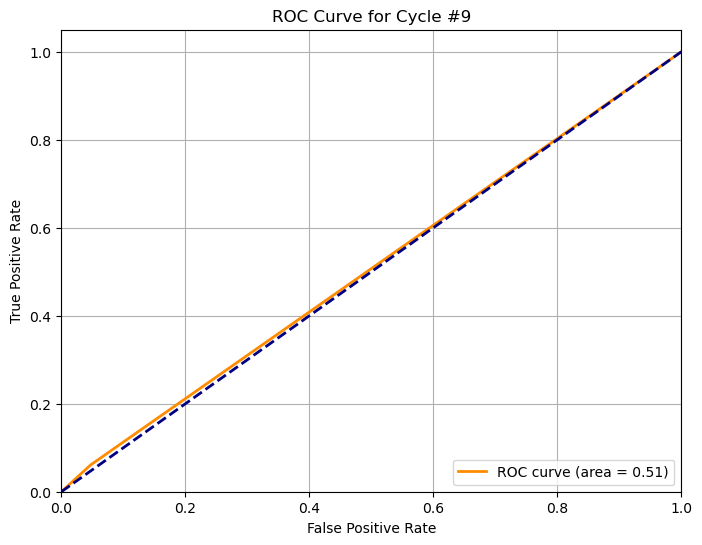

0.6430234462494512

0.5866666666666667

0.6541702985971517

0.3520320955247369

0.48504256327254025

...

0.6395387998731663

0.6395387998731663

0.6430234462494512

0.5139940529625884

RESULTS FOR CYCLE MLP#9
Accuracy: 0.7702
F1-Score: 0.1395
MCC: 0.0606


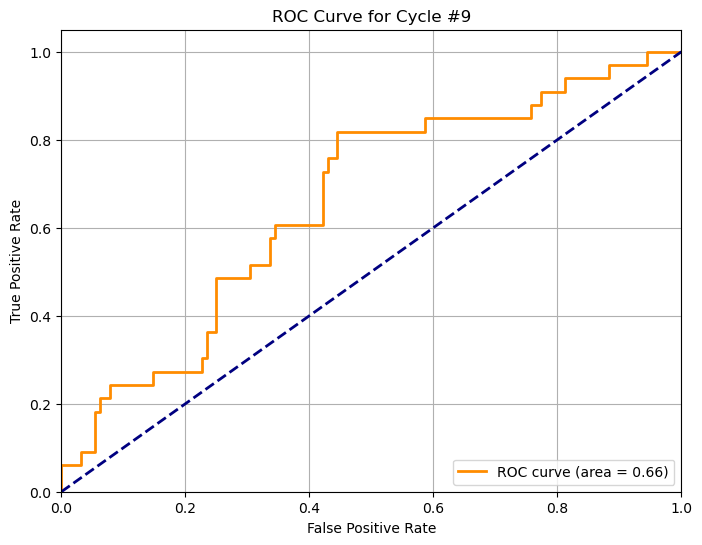

,0,1,2,3,4,5,6,7,8,9,...,2426,2427,2428,2429,2430,2431,2432,2433,2434,2435
0,0.657444,0.532463,-0.292546,1.154510,-1.314691,-1.080504,1.428492,1.242568,1.768704,-0.905249,...,6.30476,0.979778,-0.090815,-0.260165,-0.183920,-0.173077,-0.354982,-0.064084,-0.298474,-0.919614
1,-0.598825,0.123169,-0.063283,0.933877,-0.822369,0.260939,0.544541,0.122957,0.546824,-2.035174,...,-0.15861,-0.661014,-0.090815,-0.260165,5.437141,5.116579,-0.354982,-0.064084,-0.298474,-1.139512
2,-0.599645,-0.674927,0.289047,0.162925,-0.193170,-1.714463,-0.481185,0.417488,0.560735,-1.322584,...,-0.15861,-0.661014,-0.090815,-0.260165,-0.183920,-0.173077,-0.354982,-0.064084,-0.298474,-1.369254
3,0.394839,-1.051445,0.815971,0.943193,-0.407551,1.663682,1.267197,-0.374750,-0.907261,1.271680,...,-0.15861,0.979778,-0.090815,-0.260165,-0.183920,-0.173077,-0.354982,-0.064084,-0.298474,-0.613170
4,-1.185098,0.707335,-0.395997,-1.782176,1.751973,0.667886,-0.548240,-1.830887,-0.753479,-1.529913,...,-0.15861,-0.661014,-0.090815,-0.260165,-0.183920,-0.173077,-0.354982,-0.064084,-0.298474,1.514419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793,0.421003,0.141468,-1.663447,0.078307,0.140058,-1.059356,-0.203244,-0.183511,0.113116,-0.206892,...,-0.15861,1.477060,-0.090815,-0.260165,-0.183920,-0.173077,-0.354982,-0.064084,-0.298474,0.672284
794,-0.814474,-0.625526,-0.658103,1.040217,-0.385971,-0.582981,-0.051105,0.050898,1.227905,0.198041,...,-0.15861,-0.661014,-0.090815,-0.260165,-0.183920,-0.173077,-0.354982,-0.064084,-0.298474,-1.041899
795,1.269712,0.989416,-0.776988,-0.149567,-1.777697,-0.683994,1.065256,0.639162,-1.006916,0.540310,...,-0.15861,0.979778,-0.090815,-0.260165,-0.183920,-0.173077,-0.354982,-0.064084,-0.298474,0.973042
796,0.654850,-0.371210,-1.461386,-0.033219,0.977925,0.212040,-1.101276,-0.431140,-0.580818,-0.593774,...,-0.15861,-0.661014,-0.090815,-0.260165,-0.183920,-0.173077,-0.354982,-0.064084,-0.298474,-0.376794


'SVC'

0.42386851278318877

0.42386851278318877

0.42386851278318877

...

0.4091159297326251

0.4091159297326251

0.4091159297326251

0.4091159297326251

RESULTS FOR CYCLE KNN#10
Accuracy: 0.8086
F1-Score: 0.4364
MCC: 0.3364
RESULTS FOR CYCLE SVC#10
Accuracy: 0.8272
F1-Score: 0.3636
MCC: 0.3509


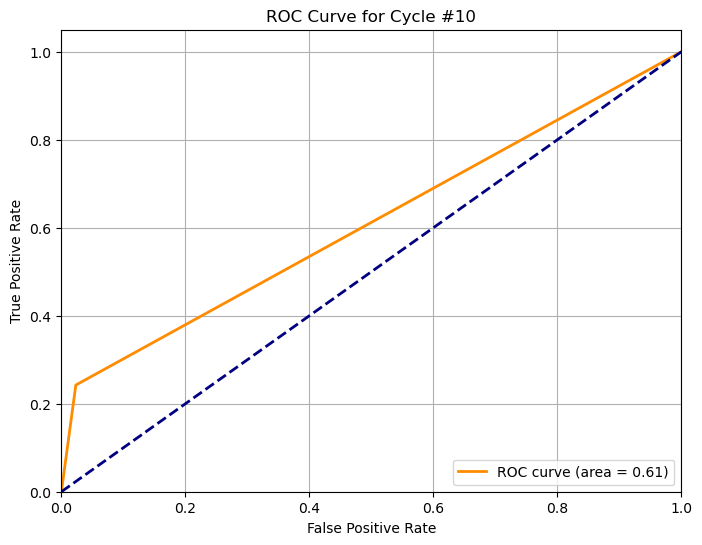

0.3059292103616908

0.0

0.25661655550655454

0.4363870967741936

0.25661655550655454

...

0.25661655550655454

0.25661655550655454

0.3057357980329625

0.25661655550655454

RESULTS FOR CYCLE MLP#10
Accuracy: 0.8086
F1-Score: 0.3404
MCC: 0.2808


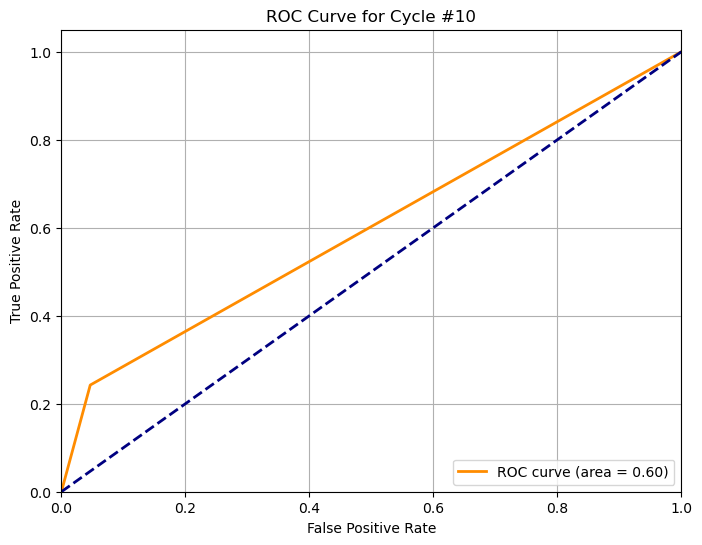

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# --- Metrics and plotting libraries ---
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

pred_val_svc = []
pred_test_svc = []

pred_val_knn = []
pred_test_knn = []

pred_val_mlp = []
pred_test_mlp = []
# pred_val_xgb = []
# pred_test_xgb = []
# --- Your main loop starts here ---
for i in range(1,11):
    x1 = pd.read_csv(f"mod_data/X1.{i}", index_col="QSPRID")
    x2 = pd.read_csv(f"mod_data/X2.{i}", index_col="QSPRID")
    x3 = pd.read_csv(f"mod_data/X3.{i}", index_col="QSPRID")
    y1 = pd.read_csv(f"mod_data/y1.{i}", index_col="QSPRID")
    y2 = pd.read_csv(f"mod_data/y2.{i}", index_col="QSPRID")
    y3 = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    x1.columns = x1.columns.astype(str)
    x2.columns = x2.columns.astype(str)
    x3.columns = x3.columns.astype(str)

    imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
    x1 = imp_mean.fit_transform(x1)
    x2 = imp_mean.transform(x2)
    x3 = imp_mean.transform(x3)
    scaler = StandardScaler()
    scaler.fit(x1)
    x1 = scaler.transform(x1)
    x2 = scaler.transform(x2)
    x3 = scaler.transform(x3)

    smote = SMOTE(sampling_strategy=1, random_state=42)
    x1, y1 = smote.fit_resample(x1, y1)
    display(pd.DataFrame(x1))

    pca = PCA(n_components=0.95, random_state = 69)
    pca.fit(x1)
    cum_var = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.argmax(cum_var >= 0.95) + 1
    pca = PCA(n_components=n_components, random_state = 69)
    x1 = pca.fit_transform(x1)
    x2 = pca.transform(x2)
    x3 = pca.transform(x3)

    y1 =  y1.values.ravel()
    y2 = y2.values.ravel()
    y3 = y3.values.ravel()
    display("SVC")
    best_mcc_this_run_svc = -1
    best_val_results_this_run_svc = []
    best_test_results_this_run_svc = []
    for j in best_results_svc_dicts:
        svc = SVC(**j, random_state=69)
        svc.fit(x1, y1)
        pred = svc.predict(x2)
        mcc = matthews_corrcoef(y2, pred > 0.5)
        display(mcc)
        if mcc > best_mcc_this_run_svc:
            best_mcc_this_run_svc = mcc
            best_val_results_this_run_svc = svc.predict(x2)
            best_test_results_this_run_svc = svc.predict(x3)
    pred_val_svc.append(best_val_results_this_run_svc)
    pred_test_svc.append(best_test_results_this_run_svc)
    # Get binary predictions

    best_mcc_this_run = -1
    best_val_results_this_run = []
    best_test_results_this_run = []
    display("KNN")
    for j in best_results_knn_dicts:
        knn = KNeighborsClassifier(**j)
        knn.fit(x1, y1)
        pred = knn.predict(x2)
        mcc = matthews_corrcoef(y2, pred)
        display(mcc)
        if mcc > best_mcc_this_run:
            best_mcc_this_run = mcc
            best_val_results_this_run = knn.predict(x2)
            best_test_results_this_run = knn.predict(x3)
    pred_val_knn.append(best_val_results_this_run)
    pred_test_knn.append(best_test_results_this_run)

    # --- Start: New code for metrics and plotting at the end of each cycle ---

    # I am assuming your model has a `predict_proba` method to get probabilities for the ROC curve.

    pred = pred_test_knn[-1]
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE KNN#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print("="*30)

    pred = pred_test_svc[-1]
    pred_proba = pred > 0.5
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE SVC#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print("="*30)
        # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y3, pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current cycle
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Cycle #{i}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    best_mcc_this_run_mlp = -1
    best_val_results_this_run_mlp = []
    best_test_results_this_run_mlp = []
    for j in best_results_mlp_dicts:
        if isinstance(j["optimizer"], str):
            j["optimizer"] = eval("optim." + j["optimizer"])
        if isinstance(j["neuron_layers"], str):
            j["neuron_layers"] = eval(j["neuron_layers"])
        j["batch_size"] = int(j["batch_size"])
        j["n_epochs"] = int(j["n_epochs"])
        mlp = MultiLayerPerceptron(x1.shape[1], n_class=1,act_fun=F.selu, device="cuda", **j, seed=69)
        mlp.fit(x1, y1, x2,y2)
        pred = mlp.predict(x2)>0.5
        mcc = matthews_corrcoef(y2, pred)
        display(mcc)
        if mcc > best_mcc_this_run:
            best_mcc_this_run = mcc
            best_val_results_this_run_mlp = mlp.predict(x2)
            best_test_results_this_run_mlp = mlp.predict(x3)
    pred_val_mlp.append(best_val_results_this_run_mlp)
    pred_test_mlp.append(best_test_results_this_run_mlp)
    # Get binary predictions


    # --- Start: New code for metrics and plotting at the end of each cycle ---

    # I am assuming your model has a `predict_proba` method to get probabilities for the ROC curve.
    pred_proba = pred_test_mlp[-1]
    pred = pred_proba > 0.5
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE MLP#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y3, pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current cycle
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Cycle #{i}')
    plt.legend(loc="lower right")
    plt.grid(True)



    plt.show() # This will display the plot for the current cycle

    print("="*30)
    # --- End: New code ---
    # --- End: New code ---



In [18]:
best_results_mlp_dicts

[{'dropout_frac': 0.0444435099611828,
  'patience': 88,
  'tol': 1.3257113655901082e-05,
  'weight_decay': 0.1,
  'n_epochs': 1691,
  'batch_size': 1024,
  'optimizer': torch.optim.rmsprop.RMSprop,
  'lr': 1e-05,
  'neuron_layers': [4000, 2000, 2000, 500]},
 {'dropout_frac': 0.5260422505035018,
  'patience': 184,
  'tol': 6.250551925273976e-05,
  'weight_decay': 0.0002811768697974,
  'n_epochs': 421,
  'batch_size': 1024,
  'optimizer': torch.optim.adamw.AdamW,
  'lr': 0.01,
  'neuron_layers': [4000, 2000, 1000, 500]},
 {'dropout_frac': 0.5425436025735909,
  'patience': 40,
  'tol': 0.0010481131341546,
  'weight_decay': 0.0001098541141987,
  'n_epochs': 1737,
  'batch_size': 512,
  'optimizer': torch.optim.rmsprop.RMSprop,
  'lr': 1e-05,
  'neuron_layers': [2048, 1024, 512, 256, 128, 64, 32, 16, 8]},
 {'dropout_frac': 0.7650149482219141,
  'patience': 90,
  'tol': 0.0002559547922699,
  'weight_decay': 0.0047148663634573,
  'n_epochs': 1103,
  'batch_size': 64,
  'optimizer': torch.opti

In [19]:
all_y3 =[]
mcc_list = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3.append(y_test)
    mcc_list.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


In [20]:
display(mcc_list)

[0.1905198432638073,
 0.05179579395086427,
 -0.032105718724445086,
 0.2095969026693416,
 0.21297173419325544,
 0.1925493100306566,
 0.2299084675051709,
 0.1939441363585449,
 0.060581636722749785,
 0.28081438423200855]

In [21]:
display(all_y3)

[QSPRID
 A2ARDataset_000    False
 A2ARDataset_001    False
 A2ARDataset_002    False
 A2ARDataset_003     True
 A2ARDataset_004    False
                    ...  
 A2ARDataset_159     True
 A2ARDataset_160     True
 A2ARDataset_161    False
 A2ARDataset_162    False
 A2ARDataset_163     True
 Name: Y, Length: 164, dtype: bool,
 QSPRID
 CK1Dataset_000    False
 CK1Dataset_001     True
 CK1Dataset_002    False
 CK1Dataset_003    False
 CK1Dataset_004     True
                   ...  
 CK1Dataset_159     True
 CK1Dataset_160    False
 CK1Dataset_161     True
 CK1Dataset_162    False
 CK1Dataset_163     True
 Name: Y, Length: 164, dtype: bool,
 QSPRID
 CK1Dataset_000    False
 CK1Dataset_001     True
 CK1Dataset_002    False
 CK1Dataset_003    False
 CK1Dataset_004    False
                   ...  
 CK1Dataset_157    False
 CK1Dataset_158     True
 CK1Dataset_159     True
 CK1Dataset_160    False
 CK1Dataset_161     True
 Name: Y, Length: 162, dtype: bool,
 QSPRID
 CK1Dataset_000     True

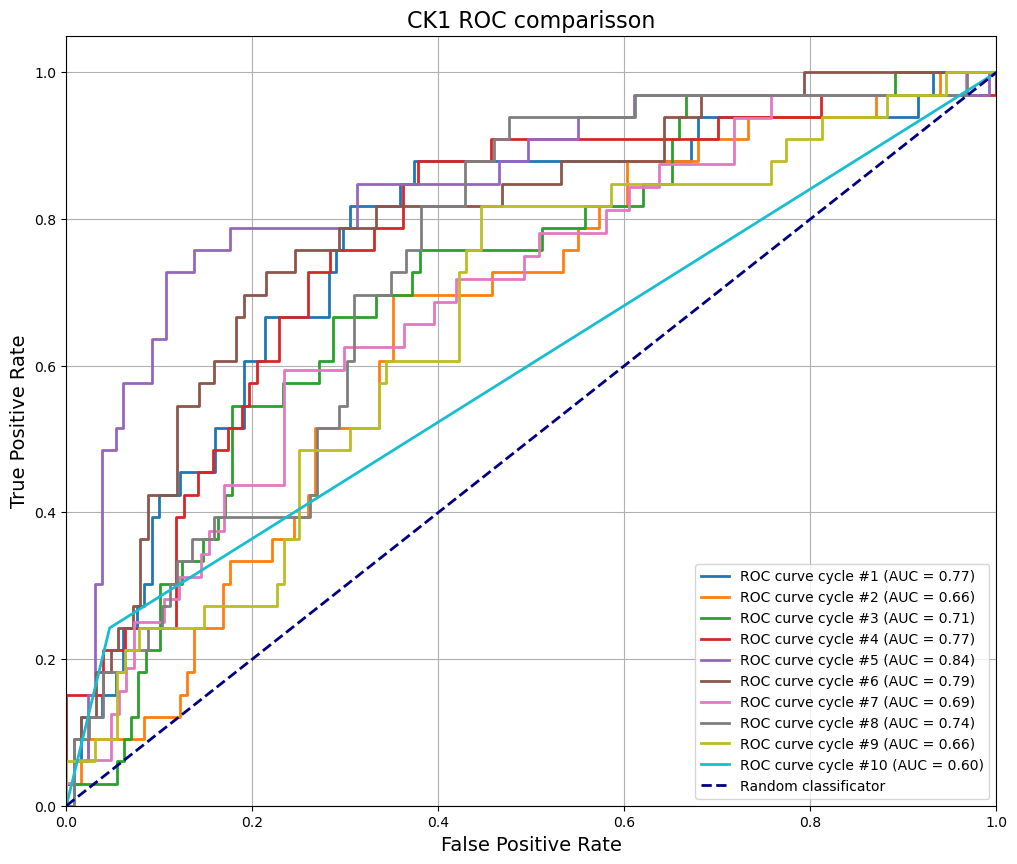

In [23]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"



plt.figure(figsize=(12, 10))

# Projdeme všechny uložené predikce a skutečné hodnoty
for i in range(len(pred_test_mlp)):
    
    # Získáme data pro i-tý cyklus
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    
    # Vypočítáme ROC křivku a AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Vykreslíme křivku pro tento cyklus do společného grafu
    # (i + 2) použijeme pro správné číslování cyklů, protože váš cyklus začínal od 2
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve cycle #{i + 1} (AUC = {roc_auc:.2f})')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classificator')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('CK1 ROC comparisson', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

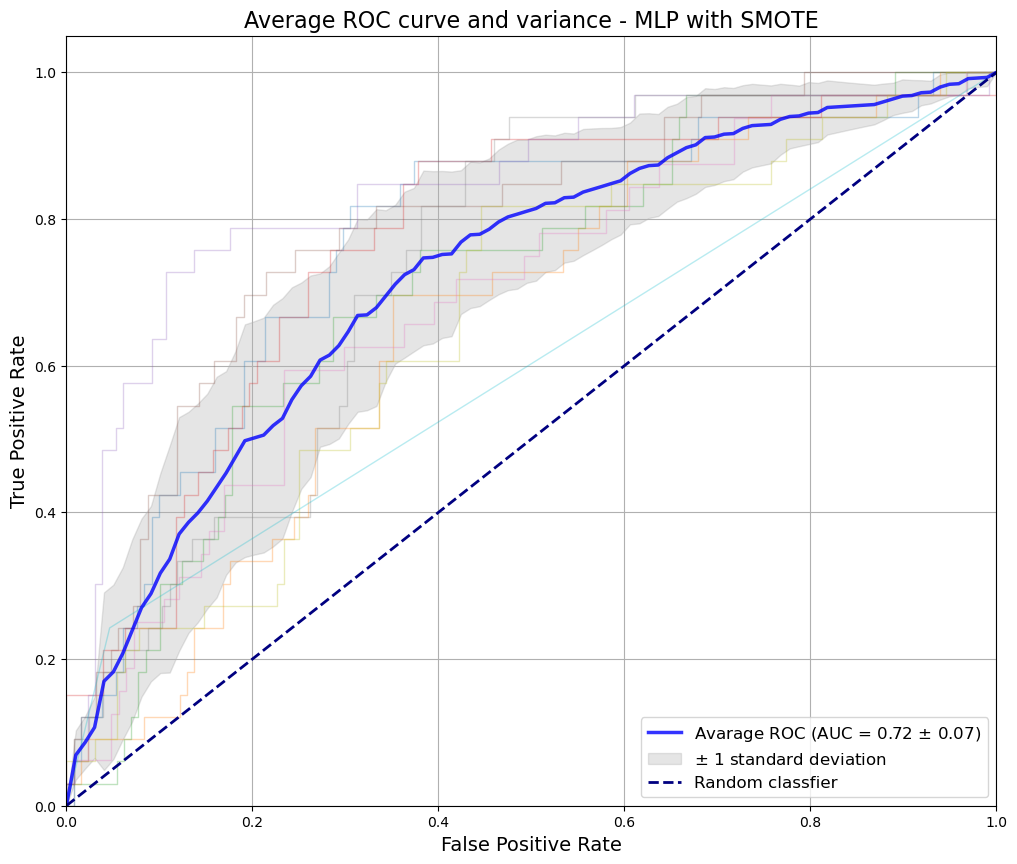

In [55]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"

# Seznamy pro ukládání výsledků pro průměrování
tprs = []
aucs = []
# Vytvoření společné osy X (False Positive Rate) pro interpolaci
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(12, 10))

# Cyklus pro výpočet a vykreslení jednotlivých křivek
for i in range(len(pred_test_mlp)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Vykreslení jednotlivých křivek (volitelné, s menší viditelností)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
             
    # Interpolace TPR na společné ose mean_fpr a uložení
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Výpočet průměrné křivky a směrodatné odchylky
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 # Zajistíme, že křivka končí v bodě [1,1]
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vykreslení průměrné křivky
plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

# Vykreslení pásma směrodatné odchylky
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - MLP with SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.savefig('mcc_roc_ck1.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
all_y3_knn =[]
mcc_list_knn = []
f1_list_knn = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_knn.append(y_test)
    f1_list_knn.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))
    mcc_list_knn.append(matthews_corrcoef(y_test, (pred_test_knn[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


In [43]:
all_y3_mlp =[]
mcc_list_mlp = []
f1_list_mlp = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_mlp.append(y_test)
    mcc_list_mlp.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))
    f1_list_mlp.append(f1_score(y_test, (pred_test_mlp[i-1]>0.5)))
    print(mcc_list_mlp[-1])

1
0.1905198432638073
2
0.05179579395086427
3
-0.032105718724445086
4
0.2095969026693416
5
0.21297173419325544
6
0.1925493100306566
7
0.2299084675051709
8
0.1939441363585449
9
0.060581636722749785
10
0.28081438423200855


In [44]:
all_y3_svc =[]
mcc_list_svc = []
f1_list_svc = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_svc.append(y_test)
    f1_list_svc.append(f1_score(y_test, (pred_test_svc[i-1]>0.5)))
    mcc_list_svc.append(matthews_corrcoef(y_test, (pred_test_svc[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


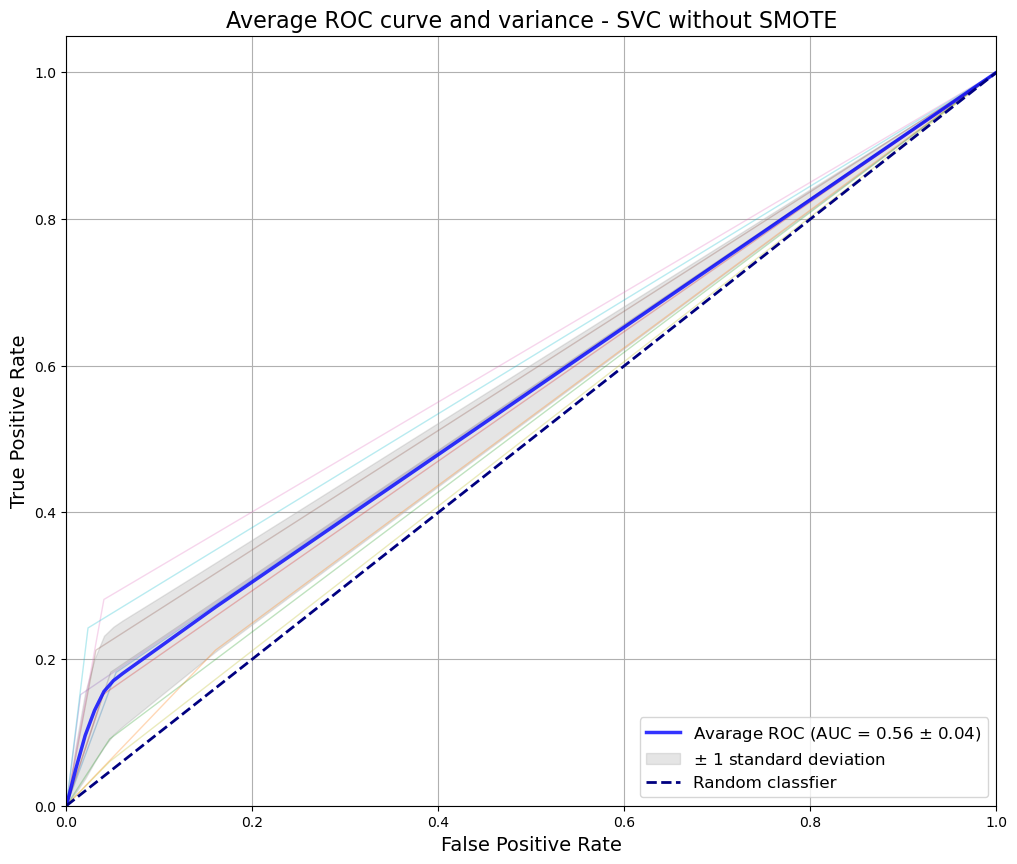

In [29]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"

# Seznamy pro ukládání výsledků pro průměrování
tprs = []
aucs = []
# Vytvoření společné osy X (False Positive Rate) pro interpolaci
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(12, 10))

# Cyklus pro výpočet a vykreslení jednotlivých křivek
for i in range(len(pred_test_mlp)):
    y_true = all_y3_svc[i]
    y_pred_proba = pred_test_svc[i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Vykreslení jednotlivých křivek (volitelné, s menší viditelností)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
             
    # Interpolace TPR na společné ose mean_fpr a uložení
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Výpočet průměrné křivky a směrodatné odchylky
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 # Zajistíme, že křivka končí v bodě [1,1]
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vykreslení průměrné křivky
plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

# Vykreslení pásma směrodatné odchylky
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - SVC without SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.show()

In [30]:
mcc_list_mlp_ws = [0.26268317748120334,
  -0.021336989228845023,
  0.2506281363689491,
  0.4674882183470144,
  0.35159487979323883,
  0.45382728197251787,
  0.000815781182587399,
  0.3325755290701754,
  0.18129553989943498,
  0.33548029539041146]
mcc_list_knn_ws =  [0.08792480672065253,
  -0.07316577794126737,
  0.2455118628324273,
  0.22460915465170275,
  0.11974269912232974,
  0.28826493717718243,
  0.3063358324269934,
  -0.003353232334378716,
  0.16712096432279652,
  0.30192735471732546]
mcc_list_svc_ws = [0.2460108552930142,
  0.13604982582081104,
  0.2787949980076138,
  0.1471301684021711,
  0.16942657217386592,
  0.14732666664642455,
  0.09009930216419205,
  0.14732666664642455,
  0.18836915825000328,
  0.2787949980076138]





In [53]:
f1_list_mlp_ws = [0.40625,
  0.24175824175824176,
  0.3793103448275862,
  0.5714285714285714,
  0.45614035087719296,
  0.5753424657534246,
  0.2857142857142857,
  0.48717948717948717,
  0.34375,
  0.4482758620689655]
f1_list_knn_ws =   [0.10526315789473684,
  0.12903225806451613,
  0.30434782608695654,
  0.20512820512820512,
  0.15,
  0.3181818181818182,
  0.35555555555555557,
  0.05263157894736842,
  0.1951219512195122,
  0.34782608695652173]
f1_list_svc_ws = [0.34615384615384615,
  0.29508196721311475,
  0.2857142857142857,
  0.2692307692307692,
  0.22727272727272727,
  0.2222222222222222,
  0.23076923076923078,
  0.2222222222222222,
  0.2608695652173913,
  0.2857142857142857]






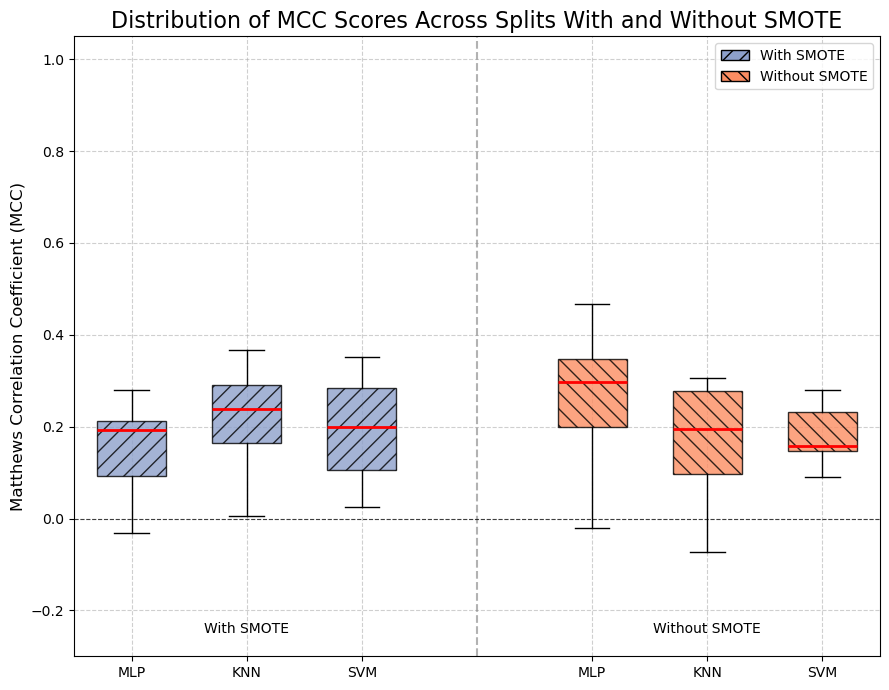

In [56]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(9, 7))

# Data
data = [mcc_list_mlp, mcc_list_knn, mcc_list_svc,
        mcc_list_mlp_ws, mcc_list_knn_ws, mcc_list_svc_ws]

# Vlastní pozice pro mezery mezi skupinami
positions = [1, 2, 3, 5, 6, 7]

# Vykreslení boxplotu na definovaných pozicích
bplot = plt.boxplot(data,
                    positions=positions,
                    patch_artist=True,
                    widths=0.6)

# Barvy a šrafování
smote_color = '#8da0cb'
non_smote_color = '#fc8d62'
smote_hatch = '//'
non_smote_hatch = '\\\\'
median_color = 'red'

# Úprava boxů
for i, box in enumerate(bplot['boxes']):
    if i < 3:
        box.set_facecolor(smote_color)
        box.set_hatch(smote_hatch)
    else:
        box.set_facecolor(non_smote_color)
        box.set_hatch(non_smote_hatch)
    box.set_edgecolor('black')
    box.set_alpha(0.8)

# Mediány
for median in bplot['medians']:
    median.set_color(median_color)
    median.set_linewidth(2)

# X-osa – popisky
plt.xticks([1, 2, 3, 5, 6, 7], ['MLP', 'KNN', 'SVM', 'MLP', 'KNN', 'SVM'])

# Oddělující čára mezi skupinami
plt.axvline(x=4, color='gray', linestyle='--', alpha=0.6)
plt.text(2, -0.25, 'With SMOTE', ha='center', fontsize=10)
plt.text(6, -0.25, 'Without SMOTE', ha='center', fontsize=10)

# Titulek a osy
plt.title('Distribution of MCC Scores Across Splits With and Without SMOTE', fontsize=16)
plt.ylabel('Matthews Correlation Coefficient (MCC)', fontsize=12)
plt.ylim([-0.3, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)

# Add a horizontal line at MCC = 0
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

# Legenda
smote_patch = mpatches.Patch(facecolor=smote_color, edgecolor='black', hatch=smote_hatch, label='With SMOTE')
non_smote_patch = mpatches.Patch(facecolor=non_smote_color, edgecolor='black', hatch=non_smote_hatch, label='Without SMOTE')
plt.legend(handles=[smote_patch, non_smote_patch], loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('mcc_boxplot_ck1.png', dpi=300, bbox_inches='tight')
plt.show()


In [32]:
display(mcc_list_knn)

[0.36669454141239677,
 0.04346601729901178,
 0.0061747965158871305,
 0.1480815848997555,
 0.2783846906609838,
 0.2506970438905309,
 0.2140462608328655,
 0.22677216045305917,
 0.2942074616088126,
 0.33637220719324384]

In [33]:
display(mcc_list_svc)

[0.1905198432638073,
 0.0552086249707639,
 0.07806259944213187,
 0.1874534328026514,
 0.2702239455289357,
 0.28826493717718243,
 0.340379871900178,
 0.20603578944537568,
 0.02550793665979526,
 0.3508690026946019]

In [34]:
display(mcc_list_mlp)

[0.1905198432638073,
 0.05179579395086427,
 -0.032105718724445086,
 0.2095969026693416,
 0.21297173419325544,
 0.1925493100306566,
 0.2299084675051709,
 0.1939441363585449,
 0.060581636722749785,
 0.28081438423200855]

In [35]:
display(mcc_list_mlp_ws)

[0.26268317748120334,
 -0.021336989228845023,
 0.2506281363689491,
 0.4674882183470144,
 0.35159487979323883,
 0.45382728197251787,
 0.000815781182587399,
 0.3325755290701754,
 0.18129553989943498,
 0.33548029539041146]

In [36]:
np.mean(mcc_list_mlp_ws)

0.26150518502766873

In [38]:
np.var(mcc_list_mlp_ws, ddof=1)

0.028063134298639374

In [54]:
import pandas as pd
import numpy as np


def create_string(list_vals):
    return f"{np.mean(list_vals):.4f} ± {np.var(list_vals, ddof=1):.4f}"
# Příklad dat
data = {
    "Model": ["MLP", "MLP without SMOTE", "KNN", "KNN without SMOTE", "SVM", "SVM without SMOTE"],
    "F1": [create_string(f1_list_mlp), create_string(f1_list_mlp_ws), create_string(f1_list_knn), create_string(f1_list_knn_ws), create_string(f1_list_svc), create_string(f1_list_svc_ws)],
    "MCC": [create_string(mcc_list_mlp), create_string(mcc_list_mlp_ws), create_string(mcc_list_knn), create_string(mcc_list_knn_ws), create_string(mcc_list_svc), create_string(mcc_list_svc_ws)]
}


df = pd.DataFrame(data)
print(df)
latex_code = df.to_latex(index=False, escape=False)
print(latex_code)

               Model               F1              MCC
0                MLP  0.2344 ± 0.0090  0.1591 ± 0.0096
1  MLP without SMOTE  0.4195 ± 0.0123  0.2615 ± 0.0281
2                KNN  0.1591 ± 0.0096  0.2165 ± 0.0141
3  KNN without SMOTE  0.2163 ± 0.0118  0.1665 ± 0.0174
4                SVM  0.2553 ± 0.0081  0.1993 ± 0.0135
5  SVM without SMOTE  0.2645 ± 0.0016  0.1829 ± 0.0041
\begin{tabular}{lll}
\toprule
Model & F1 & MCC \\
\midrule
MLP & 0.2344 ± 0.0090 & 0.1591 ± 0.0096 \\
MLP without SMOTE & 0.4195 ± 0.0123 & 0.2615 ± 0.0281 \\
KNN & 0.1591 ± 0.0096 & 0.2165 ± 0.0141 \\
KNN without SMOTE & 0.2163 ± 0.0118 & 0.1665 ± 0.0174 \\
SVM & 0.2553 ± 0.0081 & 0.1993 ± 0.0135 \\
SVM without SMOTE & 0.2645 ± 0.0016 & 0.1829 ± 0.0041 \\
\bottomrule
\end{tabular}



In [50]:
f"{np.mean(mcc_list_mlp):.4f} ± {np.var(mcc_list_mlp, ddof=1):.4f}"

'0.1591 ± 0.0096'